# Heart Rate Estimation from NIR Facial Videos


## 1. Import libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

## 2. LOAD NIR FRAMES

In [2]:
folder_path = folder_path = "C:\\Users\\Lenovo\\OneDrive\\Desktop\\heart_rate_project\\sample_data\\Subject1\\NIR-002"

files = sorted(os.listdir(folder_path))
print(f"Total frames found: {len(files)}")

Total frames found: 1500


# 3. Preprocessing + ROI extraction

In [ ]:

signal = []
max_frames = 1500
for file in files[:max_frames]:

    if file.lower().endswith(".pgm"):
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read {file}")
            continue
    #resize image
    img = cv2.resize(img, (256, 256))
    h,w = img.shape

    # fixed forehead ROI
    forehead = img[ h//8 : h//3, w//3 : 2*w//3]

    avg_intensity = np.mean(forehead)
    signal.append(avg_intensity)

  


# 4. RAW signal Generation

Signal Shape: (1500,)


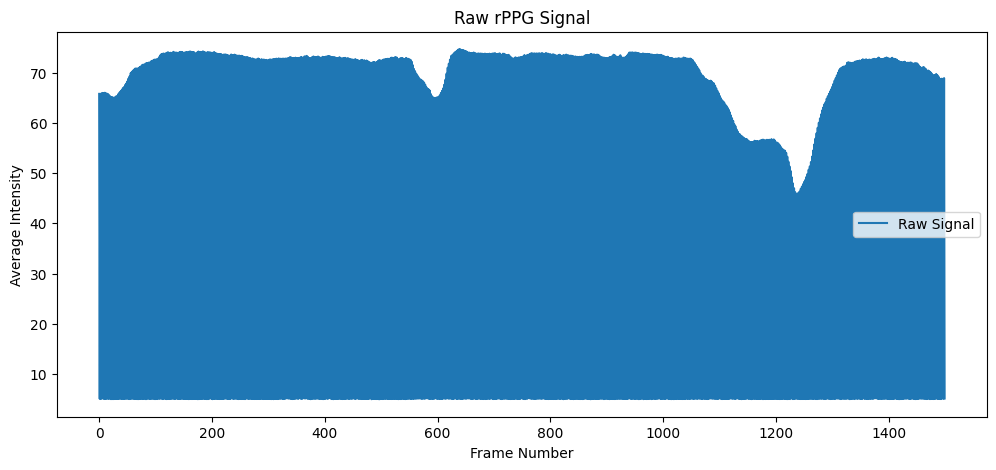

In [6]:
signal = np.array(signal)
print("Signal Shape:", signal.shape)
plt.figure(figsize = (12,5))
plt.plot(signal, label = "Raw Signal")
plt.xlabel("Frame Number")
plt.ylabel("Average Intensity")
plt.title("Raw rPPG Signal")
plt.legend()
plt.show()

# 5. Signal smoothing

In [8]:
signal = gaussian_filter1d(signal, sigma = 2)

# 6. Bandpass filtering

In [9]:
def bandpass_filter(signal, lowcut, highcut, fs, order = 4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype = 'band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

fs = 30
filtered_signal = bandpass_filter(signal, lowcut = 0.8, highcut = 3.0, fs = fs)

# 7 Filtered signal Visualization

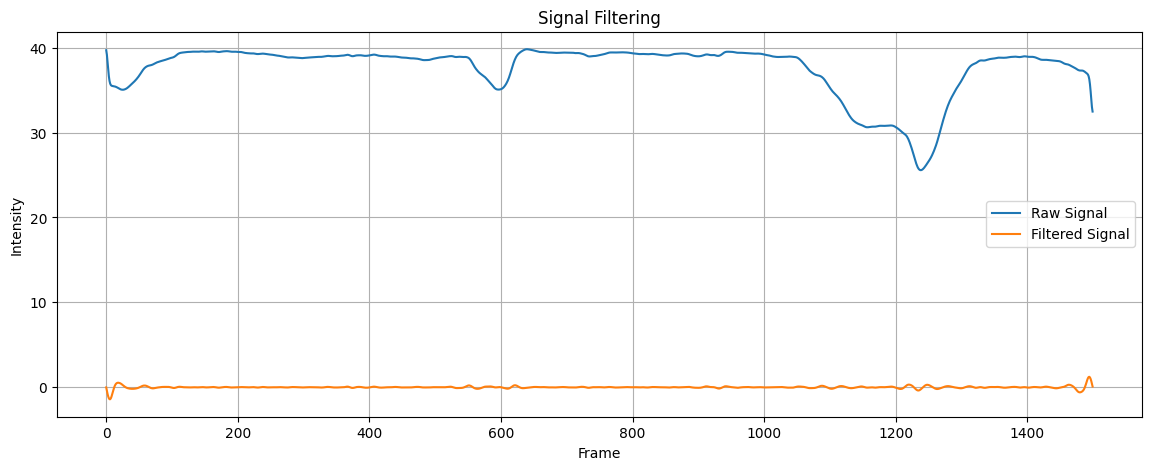

In [10]:
plt.figure(figsize = (14,5))
plt.plot(signal, label = "Raw Signal")
plt.plot(filtered_signal, label = "Filtered Signal")
plt.title("Signal Filtering")
plt.xlabel("Frame")
plt.ylabel("Intensity")
plt.legend()
plt.grid()
plt.show()


## 8. Peak detection


Detected Peaks: 73


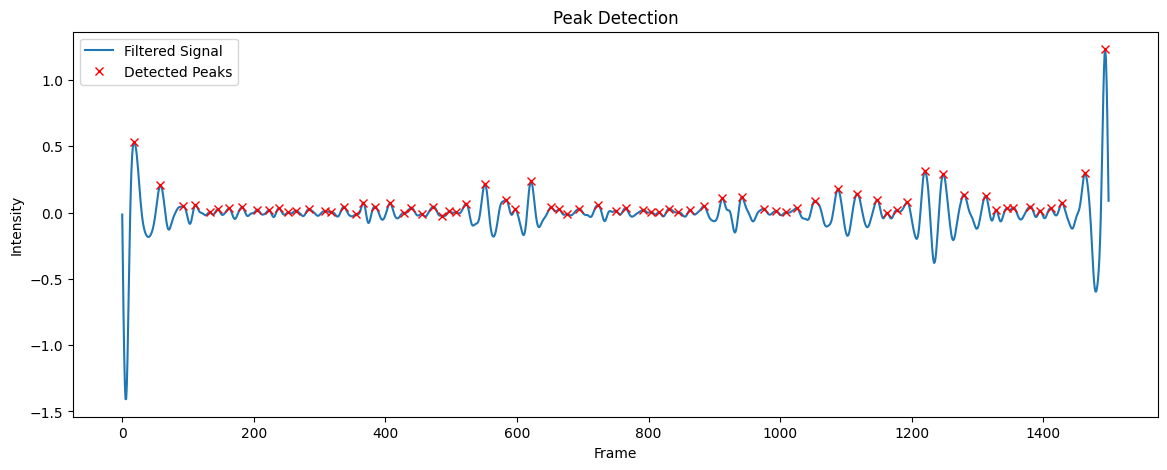

In [11]:
#8 Peak detection
peaks, _ = find_peaks( filtered_signal, distance = 10)

print("Detected Peaks:", len(peaks))
plt.figure(figsize=(14,5))

plt.plot(filtered_signal, label="Filtered Signal")

plt.plot(
    peaks,
    filtered_signal[peaks],
    "rx",
    label="Detected Peaks"
)

plt.title("Peak Detection")

plt.xlabel("Frame")

plt.ylabel("Intensity")

plt.legend()

plt.show()

## 9. BPM ESTIMATION

In [12]:
duration_seconds = len(filtered_signal) / fs

bpm = (len(peaks) / duration_seconds) * 60

print("Estimated BPM:", round(bpm,2))

Estimated BPM: 87.6


## 10. DATASET CREATION FOR DEEP LEARNING

In [14]:
sequence_length = 60

sequences = []
labels = []
for i in range(len(files) - sequence_length):

    sequence = []

    for j in range(sequence_length):

        file = files[i + j]

        if file.lower().endswith(".pgm"):

            path = os.path.join(folder_path, file)

            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (64,64))

            img = img / 255.0

            sequence.append(img)

    if len(sequence) == sequence_length:

        sequences.append(sequence)

        labels.append(bpm)
X = np.array(sequences)
y = np.array(labels)

print(X.shape)
print(y.shape)

(1440, 60, 64, 64)
(1440,)


## 11. CHANNEL DIMENSION

In [ ]:

X = np.expand_dims(X, axis=2)

print(X.shape)

(1440, 60, 1, 64, 64)


## 12. NORMALIZE LABELS

In [16]:
y = y / 100.0

## 13. CONVERT TO TENSORS

In [17]:
X_tensor = torch.tensor(X, dtype=torch.float32)

y_tensor = torch.tensor(y, dtype=torch.float32)

## 14. TRAIN / TEST/ VALIDATION  SPLIT

In [18]:
# Create data set
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tensor,
    y_tensor,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [19]:
print(X_train.shape)

print(X_val.shape)

print(X_test.shape)

torch.Size([1152, 60, 1, 64, 64])
torch.Size([144, 60, 1, 64, 64])
torch.Size([144, 60, 1, 64, 64])


## 15. CUSTOM DATASET CLASS


In [ ]:

class HeartRateDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [21]:
# Craete data set
train_dataset = HeartRateDataset(
    X_train,
    y_train
)

val_dataset = HeartRateDataset(
    X_val,
    y_val
)

test_dataset = HeartRateDataset(
    X_test,
    y_test
)

In [23]:
# Create and TRAIN LOADER

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

#validation loader
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

# Test loader

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

In [24]:
# verify
print(len(train_dataset))

print(len(val_dataset))

print(len(test_dataset))

1152
144
144


In [25]:
# ALSO VERIFY BATCH SHAPE
for X_batch, y_batch in train_loader:

    print(X_batch.shape)

    print(y_batch.shape)

    break

torch.Size([4, 60, 1, 64, 64])
torch.Size([4])


## 16. DEFINE CNN FEATURE EXTRACTOR


In [ ]:
class CNNFeatureExtractor(nn.Module):

    def __init__(self):

        super(CNNFeatureExtractor, self).__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

    def forward(self, x):

        x = self.cnn(x)

        x = x.view(x.size(0), -1)

        return x

## 17. CNN + LSTM MODEL

In [ ]:

class CNNLSTM(nn.Module):

    def __init__(self):

        super(CNNLSTM, self).__init__()

        self.cnn = CNNFeatureExtractor()

        self.lstm = nn.LSTM(
            input_size=4096,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(256, 1)

    def forward(self, x):

        batch_size, seq_len, c, h, w = x.size()

        cnn_features = []

        for t in range(seq_len):

            frame = x[:, t]

            feature = self.cnn(frame)

            cnn_features.append(feature)

        cnn_features = torch.stack(cnn_features, dim=1)

        lstm_out, _ = self.lstm(cnn_features)

        final_output = lstm_out[:, -1, :]

        bpm = self.fc(final_output)

        return bpm

## 18. MODEL INITIALIZATION

In [ ]:

model = CNNLSTM()

print(model)

CNNLSTM(
  (cnn): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
      (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (9): Dropout(p=0.3, inplace=False)
    )
  )
  (lstm): LSTM(4096, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


## 18. DEFINE LOSS FUNCTION


In [ ]:
criterion = nn.L1Loss()

## 19. OPTIMIZER

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

## 20. DEVICE SETUP


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

## 21. Training loop


In [ ]:
train_loss_history = []

val_loss_history = []

epochs = 20

for epoch in range(epochs):

    # ================= TRAINING =================

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        # move data to device
        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        # reshape labels
        y_batch = y_batch.view(-1,1)

        # forward pass
        outputs = model(X_batch)

        # calculate loss
        loss = criterion(outputs, y_batch)

        # clear old gradients
        optimizer.zero_grad()

        # backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        # accumulate loss
        running_loss += loss.item()

    # average training loss
    train_loss = running_loss / len(train_loader)

    # ================= VALIDATION =================

    model.eval()

    val_running_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            y_batch = y_batch.view(-1,1)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_running_loss += loss.item()

    # average validation loss
    val_loss = val_running_loss / len(val_loader)

    # ================= STORE LOSSES =================

    train_loss_history.append(train_loss)

    val_loss_history.append(val_loss)

    # ================= PRINT =================

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/20] | Train Loss: 0.0364 | Val Loss: 0.0068
Epoch [2/20] | Train Loss: 0.0159 | Val Loss: 0.0211
Epoch [3/20] | Train Loss: 0.0113 | Val Loss: 0.0096
Epoch [4/20] | Train Loss: 0.0098 | Val Loss: 0.0121
Epoch [5/20] | Train Loss: 0.0079 | Val Loss: 0.0044
Epoch [6/20] | Train Loss: 0.0073 | Val Loss: 0.0075
Epoch [7/20] | Train Loss: 0.0064 | Val Loss: 0.0058
Epoch [8/20] | Train Loss: 0.0061 | Val Loss: 0.0091
Epoch [9/20] | Train Loss: 0.0051 | Val Loss: 0.0016
Epoch [10/20] | Train Loss: 0.0058 | Val Loss: 0.0050
Epoch [11/20] | Train Loss: 0.0045 | Val Loss: 0.0033
Epoch [12/20] | Train Loss: 0.0044 | Val Loss: 0.0120
Epoch [13/20] | Train Loss: 0.0048 | Val Loss: 0.0014
Epoch [14/20] | Train Loss: 0.0041 | Val Loss: 0.0068
Epoch [15/20] | Train Loss: 0.0038 | Val Loss: 0.0081
Epoch [16/20] | Train Loss: 0.0038 | Val Loss: 0.0057
Epoch [17/20] | Train Loss: 0.0036 | Val Loss: 0.0035
Epoch [18/20] | Train Loss: 0.0036 | Val Loss: 0.0006
Epoch [19/20] | Train Loss: 0.0034 | 

## 22.TRAIN vs VALIDATION LOSS PLOT


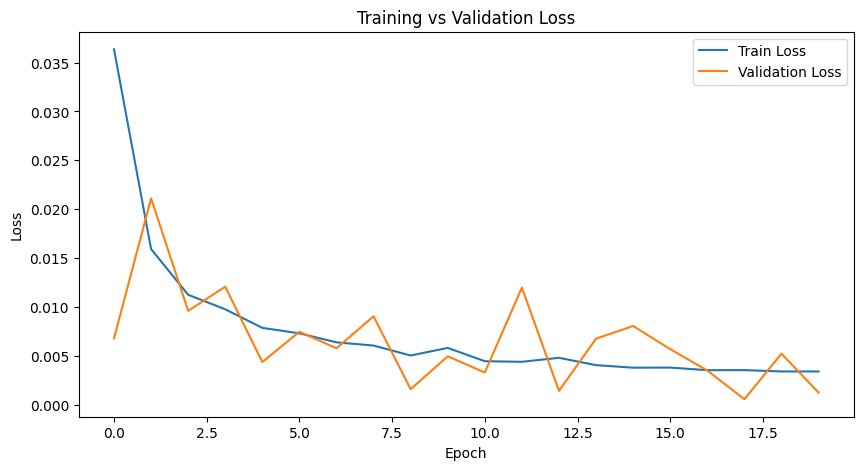

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_loss_history, label="Train Loss")

plt.plot(val_loss_history, label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

## 23. SAVE MODEL


In [ ]:

torch.save(
    model.state_dict(),
     "cnn_lstm_heart_rate_model.pth"
)
print("Model saved successfully")

Model saved successfully


## 24. MODEL EVALUATION


In [ ]:

model.eval()

predictions = []
actuals = []
with torch.no_grad():

    for X_batch, y_batch in test_loader:

        # move to device
        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        # forward pass
        outputs = model(X_batch)

        # move back to cpu
        outputs = outputs.cpu().numpy()

        y_batch = y_batch.cpu().numpy()

        # denormalize BPM
        outputs = outputs * 100

        y_batch = y_batch * 100

        # store predictions
        predictions.extend(outputs.flatten())

        actuals.extend(y_batch.flatten())

## 25.convert to numpy array


In [ ]:

predictions = np.array(predictions)

actuals = np.array(actuals)

## 26. EVALUATION METRICS

In [46]:
#MAE
mae = np.mean(
    np.abs(
        np.array(actuals) - np.array(predictions)
    )
)

print("MAE:", round(mae,2))

# RMSE
rmse = np.sqrt(
    np.mean(
        (np.array(actuals) - np.array(predictions))**2
    )
)

print("RMSE:", round(rmse,2))

# Pearson Correlation
pearson_corr = np.corrcoef(
    actuals,
    predictions
)[0,1]

print("Pearson Correlation:", round(pearson_corr,2))


MAE: 0.13
RMSE: 0.13
Pearson Correlation: nan


c:\Users\Lenovo\OneDrive\Desktop\heart_rate_project\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Lenovo\OneDrive\Desktop\heart_rate_project\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 27. PREDICTION VISUALIZATION


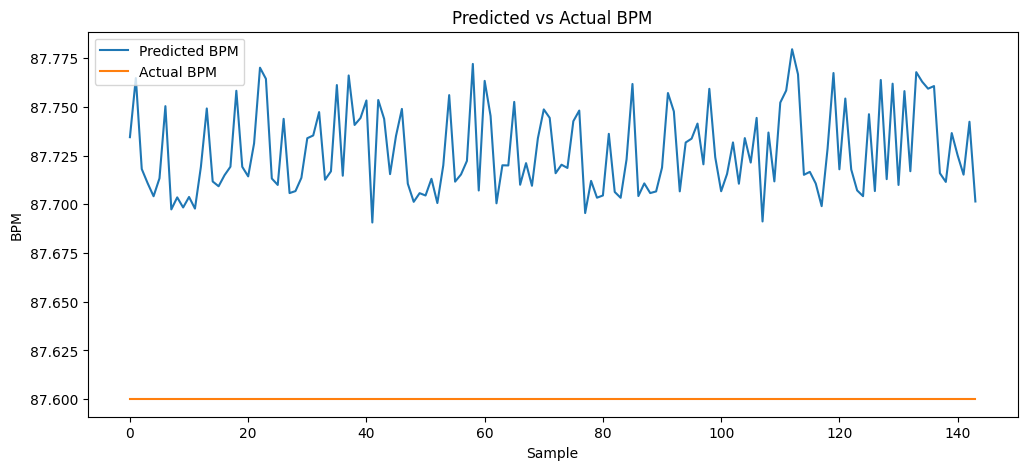

In [ ]:


plt.figure(figsize=(12,5))

plt.plot(predictions, label="Predicted BPM")

plt.plot(actuals, label="Actual BPM")

plt.title("Predicted vs Actual BPM")

plt.xlabel("Sample")

plt.ylabel("BPM")

plt.legend()

plt.show()

In [48]:
for i in range(10):

    print(
        f"Sample {i+1} | "
        f"Predicted BPM: {predictions[i]:.2f} | "
        f"Actual BPM: {actuals[i]:.2f}"
    )

Sample 1 | Predicted BPM: 87.73 | Actual BPM: 87.60
Sample 2 | Predicted BPM: 87.76 | Actual BPM: 87.60
Sample 3 | Predicted BPM: 87.72 | Actual BPM: 87.60
Sample 4 | Predicted BPM: 87.71 | Actual BPM: 87.60
Sample 5 | Predicted BPM: 87.70 | Actual BPM: 87.60
Sample 6 | Predicted BPM: 87.71 | Actual BPM: 87.60
Sample 7 | Predicted BPM: 87.75 | Actual BPM: 87.60
Sample 8 | Predicted BPM: 87.70 | Actual BPM: 87.60
Sample 9 | Predicted BPM: 87.70 | Actual BPM: 87.60
Sample 10 | Predicted BPM: 87.70 | Actual BPM: 87.60
